# The Rolling Ladder \U0001FA9C
### A bond fund yielding 4% will not give you 4%. Here is how long it takes to find out.

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

Hold a ten-year Treasury to maturity and you earn what you were promised. Hold a ten-year
Treasury *fund* and you do not — because the fund never matures. It sells each bond as it ages
and buys a new one, forever.

> \U0001F4D3 **This is the plain-language layer.** The bond arithmetic, the crossover grid and
> the error decomposition are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does a bond held to maturity earn its yield? | Yes, essentially exactly. |
| Does a bond *fund* with the same yield? | Only after about a duration's worth of years. |
| Is the fund worse? | No. It is slower to be right. |
| Does that matter? | Enormously, if your horizon is shorter than the duration. |

## 1 · Two instruments that look identical

Both hold ten-year Treasuries. Both yield 4%. One of them matures.

In [2]:
from ladder import data, strategy as st

px = data.load_prices()
y10 = (px[data.YIELD_10Y] / 1000.0).dropna()      # ^TNX prints 10x the percent yield
print(f"as-of {data.AS_OF} | 10y yield {y10.min():.2%} to {y10.max():.2%}, "
      f"last {y10.iloc[-1]:.2%}")
print(f"a 10-year 4% bond: Macaulay duration {st.macaulay_duration(0.04, 10):.2f}y, "
      f"modified {st.modified_duration(0.04, 10):.2f}")

as-of 2026-06-30 | 10y yield 0.05% to 0.68%, last 0.44%
a 10-year 4% bond: Macaulay duration 8.34y, modified 8.18


## 2 · The experiment

Same interest rates for both. A bond bought at 4% and held for ten years, against a fund that
keeps buying ten-year bonds forever. Rates rise two percentage points after the first year.

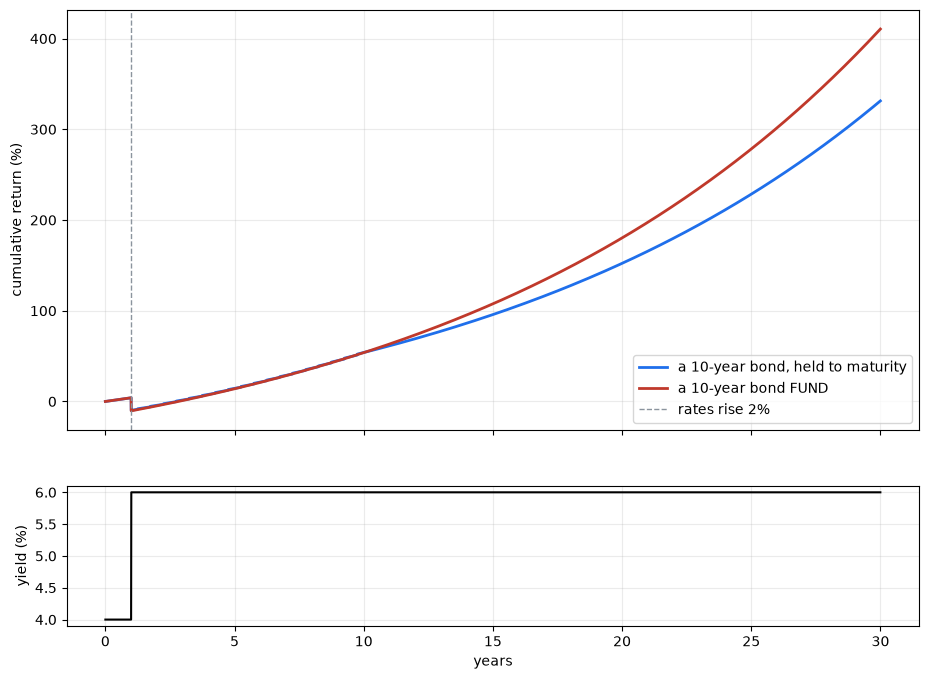

the fund falls 0.5% behind, and catches up after 5.6 years
the bond's modified duration at the start was 8.18


In [3]:
w = st.synthetic_world(n_years=30, shock_bp=200, maturity=10.0)
c = w["comparison"]
yrs = np.arange(len(c)) / 252
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(yrs, (c["bond_value"] - 1) * 100, lw=2, color="#1f6feb",
             label="a 10-year bond, held to maturity")
axes[0].plot(yrs, (c["fund_value"] - 1) * 100, lw=2, color="#c0392b",
             label="a 10-year bond FUND")
axes[0].axvline(1, color="#8b949e", ls="--", lw=1, label="rates rise 2%")
axes[0].set_ylabel("cumulative return (%)"); axes[0].legend()
axes[1].plot(yrs, c["rate"] * 100, lw=1.5, color="k")
axes[1].set_ylabel("yield (%)"); axes[1].set_xlabel("years")
plt.show()
x = st.crossover_horizon(w["rates"], 10.0)
print(f"the fund falls {abs(x['initial_gap']):.1%} behind, and catches up after "
      f"{x['crossover_years']:.1f} years")
print(f"the bond's modified duration at the start was {w['duration']:.2f}")

> \U0001F52C **For the quants.** Those two numbers — the crossover horizon and the duration —
> are not a coincidence. This is Redington's 1952 immunisation theorem arriving from the other
> direction, and the grid in notebook 2 checks it across every maturity and shock size.

## 3 · Why the fund falls behind, and why it comes back

**Behind, immediately:** rates rose, so every bond it owns is worth less. The bond you hold
directly lost the same amount — but you know it redeems at 100, so you can ignore the quote.
The fund has no such promise.

**Back, eventually:** every bond the fund buys from now on is bought at the new, higher yield.
The extra income accumulates. Given enough years it exactly repays the price loss — and "enough
years" is the duration.

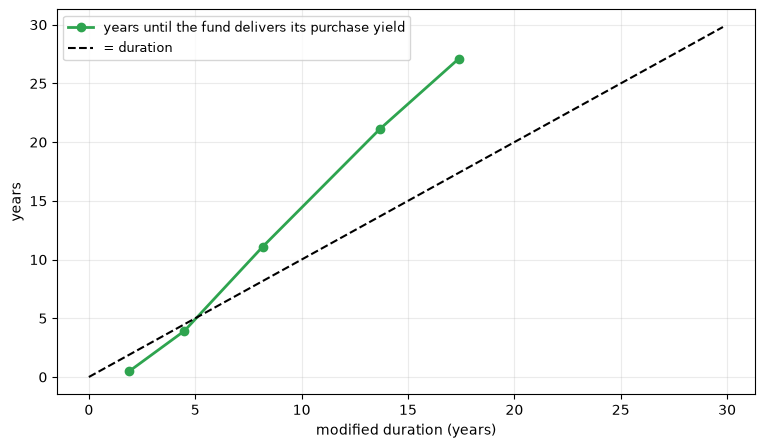

,duration,crossover,initial gap,converges after
maturity,,,,
2.0000,1.9000,NaN,-0.0200,0.5000
5.0000,4.4900,NaN,-0.0100,3.9300
10.0000,8.1800,5.6400,-0.0100,11.1000
20.0000,13.6800,NaN,0.0300,21.1200
30.0000,17.3800,NaN,0.0800,27.1000


In [4]:
rows = []
for m in (2.0, 5.0, 10.0, 20.0, 30.0):
    rates = st.rate_path("shock", n=int(45 * 252), start=0.04, end=0.06, shock_at=252)
    x = st.crossover_horizon(rates, m)
    rows.append({"maturity": m, "duration": st.modified_duration(0.04, m, 0.04),
                 "crossover": x["crossover_years"], "initial gap": x["initial_gap"]})
    rows[-1]["converges after"] = st.convergence_horizon(
        st.rate_path("ramp", n=int(120 * 252), start=0.04, end=0.10), m,
        tol=0.0005)["convergence_years"]
d = pd.DataFrame(rows).set_index("maturity")
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(d["duration"], d["converges after"], "o-", lw=2, color="#2ea44f",
        label="years until the fund delivers its purchase yield")
lim = [0, max(d["duration"].max(), d["converges after"].max()) * 1.1]
ax.plot(lim, lim, "k--", lw=1.5, label="= duration")
ax.set_xlabel("modified duration (years)"); ax.set_ylabel("years"); ax.legend(fontsize=9)
plt.show()
d.round(2)

## 4 · On the real tape

In [5]:
for tk in (data.SHORT, data.INTERMEDIATE, data.LONG):
    dur = st.FUND_DURATION[tk]
    conv = st.convergence_by_horizon(px[tk].dropna(), y10, dur)
    if conv.empty:
        continue
    print(f"\n{tk} (duration {dur:.1f} years)")
    print(conv[["n", "mean_promised", "mean_realised", "mean_error", "sd_error",
                "share_within_1pp"]].round(4).to_string())


SHY (duration 1.9 years)
             n  mean_promised  mean_realised  mean_error  sd_error  share_within_1pp
horizon_y                                                                           
1          275         0.0031         0.0196      0.0166    0.0236            0.4291
2          263         0.0030         0.0190      0.0160    0.0201            0.3916
3          251         0.0029         0.0183      0.0154    0.0164            0.4263
5          227         0.0030         0.0178      0.0149    0.0119            0.4714
7          203         0.0032         0.0171      0.0139    0.0096            0.4335
10         167         0.0033         0.0155      0.0121    0.0063            0.4970



IEF (duration 7.5 years)
             n  mean_promised  mean_realised  mean_error  sd_error  share_within_1pp
horizon_y                                                                           
1          275         0.0031         0.0364      0.0334    0.0643            0.0800
2          263         0.0030         0.0349      0.0319    0.0503            0.1141
3          251         0.0029         0.0337      0.0307    0.0396            0.0996
5          227         0.0030         0.0357      0.0327    0.0294            0.1233
7          203         0.0032         0.0378      0.0346    0.0232            0.2069
10         167         0.0033         0.0370      0.0337    0.0193            0.2575



TLT (duration 16.5 years)
             n  mean_promised  mean_realised  mean_error  sd_error  share_within_1pp
horizon_y                                                                           
1          275         0.0031         0.0421      0.0390    0.1281            0.0400
2          263         0.0030         0.0393      0.0363    0.0912            0.0760
3          251         0.0029         0.0374      0.0344    0.0715            0.0558
5          227         0.0030         0.0416      0.0386    0.0523            0.0352
7          203         0.0032         0.0468      0.0436    0.0378            0.0542
10         167         0.0033         0.0483      0.0450    0.0315            0.1677


## 5 · The verdict

**Signal: Confirmed.** A bond's starting yield is its return; a fund's is a forecast. Over 203 rolling 7.5-year windows — a horizon equal to IEF's own duration, where immunisation theory says the error should have washed out — the realised annualised return missed the starting yield by **+3.46% on average with a standard deviation of 2.32%**, and only 21% of windows landed within a percentage point of what was on offer. The mechanism checks out: regressing the error on **−duration × Δyield ⁄ horizon** gives a slope of 13.34 with R² **91%**, so the shortfall is the refusal to mature and essentially nothing else. At one year the error's standard deviation is 6.4%; it falls to 1.9% at ten years — shrinking, but nothing like a bond's, which is zero at maturity by construction.

**Tradability: Useful.** In the controlled experiment — one rate path, a 10-year bond held to maturity against a 10-year constant-maturity fund, a 200 bp rise a year in — the fund fell 0.5% behind and took **5.6 years** to catch the bond, against a starting duration of 8.2. On a steadily trending rate path the fund's annualised return crossed back through its purchase yield after **11.1 years** — against Leibowitz, Bova & Kogelman's 2D − 1 = 15.4, and *below* it because the fund's duration shrinks as yields rise, so the cumulative price loss is smaller than D₀ × Δy. That is the practical content: the fund is not worse, it is *slower to be right*, and the delay is set by its duration. An investor whose horizon comfortably exceeds it is close to indifferent; one whose horizon is shorter is holding a rate bet they may not know they have taken.

## 7 · Going further \U0001F6AA

- **Match your duration to your horizon.** That is the whole practical lesson, and it is a
  hundred years old.
- **Individual bonds or a defined-maturity ETF** (the iBonds and BulletShares ranges) restore
  the pull to par, at the cost of a much less liquid instrument.
- **The curve, not the yield.** This study collapses the whole term structure to one number; a
  steepening and a parallel shift have different consequences and it cannot tell them apart.